# SUE Earnings-Surprise Drift — a quantitative teardown 🔬
### The SUE tercile long-short · naive vs autocorrelation-robust *t* · non-monotone quintiles · the tercile-vs-decile sign flip · label-shuffle & within-quarter block placebos · an honest cost sweep · a 20-seed synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Textbook PEAD replicates%3F: Busted](https://img.shields.io/badge/Textbook_PEAD_replicates%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **post-earnings drift lines up with standardized unexpected earnings** — is the original Bernard-Thomas (1989) SUE sort. The job here is to measure it honestly on a conservative large-cap basket, respect the fact that filings cluster into earnings seasons, and ask whether anything survives.

> ⚠️ **Data note.** yfinance daily adjusted closes for a 30-name large-cap basket + EDGAR frame-tagged quarterly **diluted EPS** (with filing dates), as-of 2026-06-30, fingerprint `4d0fd3625f76`. SUE = seasonal-random-walk surprise `EPS_q − EPS_{q−4}` over the rolling std of the last ~8 such surprises. **Survivorship is named on the Signal axis** (a current-membership basket, and PEAD is documented to concentrate in small illiquids — so this basket is where it's weakest). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from sue_drift import data, strategy as st
try:
    from quantlab.repro import as_of
except Exception:
    as_of = lambda df, a: df[df.index <= pd.Timestamp(a)].copy()

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = as_of(data.load_prices(), data.AS_OF)
    EVENTS = data.load_events()
    ET = data.build_event_table(PRICES, EVENTS)
else:
    PRICES = EVENTS = ET = None
print("real cache present:", HAVE_REAL, "| SUE events:", (0 if ET is None else len(ET)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'n_names': 30, 'filed_lo': '2012-07-26', 'filed_hi': '2026-06-03', 'fp': '4d0fd3625f76', 'h21': {'n': 1315, 'top': 1.06, 'bot': 2.22, 'ls': -1.16, 't': -2.29, 'nw_t': -1.41, 'win': 50.6, 'win_lo': 47.3, 'win_hi': 53.9, 'placebo_p': 0.991, 'block_p': 0.841, 'q5': [2.04, 1.91, 0.89, -0.05, 1.74]}, 'h42': {'n': 1279, 'top': 1.7, 'bot': 3.47, 'ls': -1.77, 't': -2.48, 'nw_t': -0.41, 'win': 46.9, 'win_lo': 43.6, 'win_hi': 50.3, 'placebo_p': 0.995, 'block_p': 0.913, 'q5': [3.37, 3.49, 2.48, 0.03, 2.69]}, 'h63': {'n': 1261, 'top': 3.34, 'bot': 4.29, 'ls': -0.95, 't': -1.12, 'nw_t': 0.41, 'win': 48.9, 'win_lo': 45.5, 'win_hi': 52.3, 'placebo_p': 0.879, 'block_p': 0.628, 'q5': [3.91, 4.48, 4.1, 1.16, 4.42]}, 'gross63': -0.95, 'c5_net': -1.27, 'c10_net': -1.47, 'decile63_ls': 1.53, 'decile63_t': 0.99, 'syn_null_mean': 0.08, 'syn_null_sd': 0.57, 'syn_null_fire': 0, 'syn_planted_ls': 16.6, 'syn_planted_t': 21.5}


real cache present: True | SUE events: 1319


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | 3-mo tercile long-short **-0.95%** (wrong sign); robust calendar-time Newey-West **t = +0.41** (max over horizons |t| = 1.41); non-monotone quintiles; sign flips tercile→decile (-0.95% → +1.53%); block placebo p = 0.63 |
| **Tradability** | `MIRAGE` | net of 5/10 bps at 63d: -1.27% / -1.47% (gross already -0.95%) |
| **Textbook PEAD replicates?** | `BUSTED` | no monotone SUE gradient; robust t pinned near zero on liquid large-cap survivors |

> 💡 In plain words: the naive per-event *t* looks *significantly negative* (−2.3), but that's an artifact of earnings-season clustering — the moment you test it on a calendar-time basis or shuffle labels within quarter, there's nothing there, in either direction.

## 1 · The claim, steelmanned

Let $E_q$ be diluted EPS for fiscal quarter $q$, disclosed (filed) on date $F$. The seasonal-random-walk surprise is $u_q = E_q - E_{q-4}$, and

$$\mathrm{SUE}_q = \frac{E_q - E_{q-4}}{\operatorname{std}(u_{q-1},\dots,u_{q-8})}$$

where the denominator uses only surprises known *strictly before* $q$. The claims:

- **H₁ (drift).** Sorting events on SUE, the top-minus-bottom forward return over 1–3 months is **positive**.
- **H₂ (monotonicity).** Mean drift **rises monotonically** from the bottom SUE bucket to the top.
- **H₃ (capture).** A long-short banks the spread net of realistic costs + borrow.

We find **H₁ rejected** (spread is negative: -1.16% / -1.77% / -0.95% at 21/42/63d; robust NW t never clears +2), **H₂ rejected** (non-monotone, sign-flipping across bucket counts), **H₃ rejected** (nothing to capture).

## 2 · So what? — inference design

The honest problem with an event study is that **filings cluster in earnings seasons**, so pooled per-event returns are neither independent nor serially uncorrelated — a naive one-sample *t* is inflated (both ways). So we lead with the **autocorrelation-robust** statistic: aggregate the top-minus-bottom drift into ~50 earnings-season buckets and run a **Newey-West HAC *t*** on that calendar-time series. The naive one-sample *t* is reported alongside precisely to show the gap. We add a **within-quarter block placebo** (shuffle SUE labels inside each calendar quarter — respects the clustering), a global label-shuffle placebo, and a Wilson interval on the win-rate. The **t ≥ 2 bar is judged on the robust NW *t***.

## 3 · How we'd know — the protocol

- **Events.** 1,261 usable (ticker, filing-date) rows over 30 names, filed 2012-07-26 → 2026-06-03; each print needs ≥8 prior seasonal surprises before a SUE is emitted.
- **Execution / lag.** Anchor at the first session on/after the filing, **enter the close one day later** (signal known at the filing, return from t+1 — the single documented lag), hold 21 / 42 / 63 trading days.
- **Signal.** Top-minus-bottom SUE **tercile** long-short; one-sample *t*, calendar-time NW *t*, win-rate + Wilson, label & block placebos.
- **Monotonicity.** Quintile drift low→high; the tercile-vs-decile sign-stability check.
- **Execution.** One-way costs × per-event turnover (4× one-way on a round trip) + short-leg borrow.
- **Control.** Synthetic panel with a planted drift knob; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · The headline — naive *t* vs the robust *t*

The long-short at each horizon, with the naive one-sample *t* and the autocorrelation-robust calendar-time Newey-West *t* side by side.

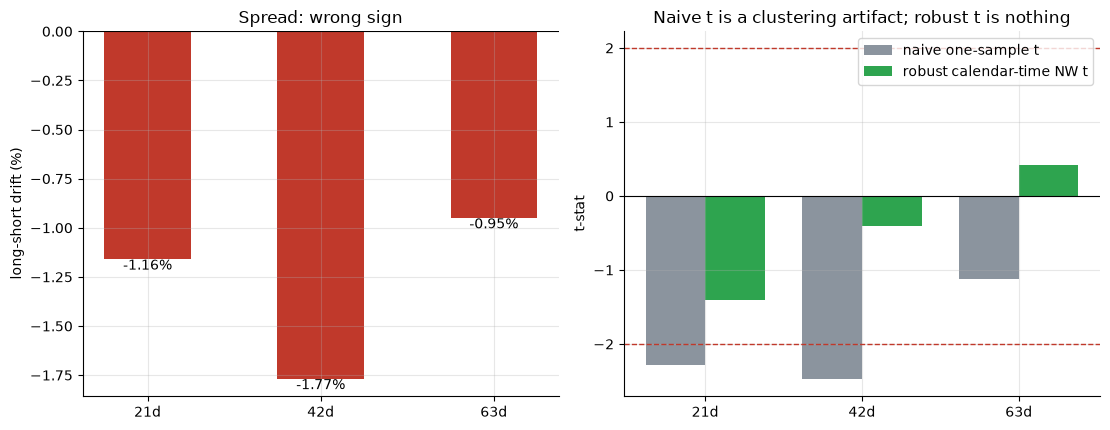

[(21, -1.16, -2.29, -1.41), (42, -1.77, -2.48, -0.41), (63, -0.95, -1.12, 0.41)]


In [2]:
rows = []
for H in st.HORIZONS:
    if HAVE_REAL:
        s = st.summarize(PRICES, ET, H, n_buckets=3, placebo=False)
        rows.append((H, s['ls_mean']*100, s['t'], s['nw_t']))
    else:
        d = R[f'h{H}']; rows.append((H, d['ls'], d['t'], d['nw_t']))
Hs = [r[0] for r in rows]; ls=[r[1] for r in rows]; tn=[r[2] for r in rows]; tw=[r[3] for r in rows]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.2, 4.4))
a1.bar([f'{h}d' for h in Hs], ls, color=RED, width=.5)
for i,v in enumerate(ls): a1.annotate(f'{v:+.2f}%',(i,v),ha='center',va='top')
a1.axhline(0,c='k',lw=.8); a1.set_ylabel('long-short drift (%)'); a1.set_title('Spread: wrong sign')
x = np.arange(len(Hs)); w=.38
a2.bar(x-w/2, tn, w, color=GREY, label='naive one-sample t')
a2.bar(x+w/2, tw, w, color=GREEN, label='robust calendar-time NW t')
a2.axhline(2, ls='--', c=RED, lw=1); a2.axhline(-2, ls='--', c=RED, lw=1); a2.axhline(0,c='k',lw=.8)
a2.set_xticks(x); a2.set_xticklabels([f'{h}d' for h in Hs]); a2.set_ylabel('t-stat')
a2.set_title('Naive t is a clustering artifact; robust t is nothing'); a2.legend()
plt.tight_layout(); plt.show()
print([(h, round(l,2), round(a,2), round(b,2)) for h,l,a,b in rows])

> 💡 In plain words: the naive one-sample *t* is a *significant* **-2.29 / -2.48** at 21/42 days — but it's the wrong sign *and* it's an artifact. The robust calendar-time Newey-West *t* collapses to **-1.41 / -0.41 / +0.41** — nowhere near the ±2 bar in either direction. H₁ is rejected: there is no drift in the predicted direction, and no robust reversal either.

### 4b · Monotonicity and the bucket-count sign flip

A real SUE drift is monotone in SUE (Foster-Olsen-Shevlin). And it keeps its sign when you re-slice the sort. Neither holds here.

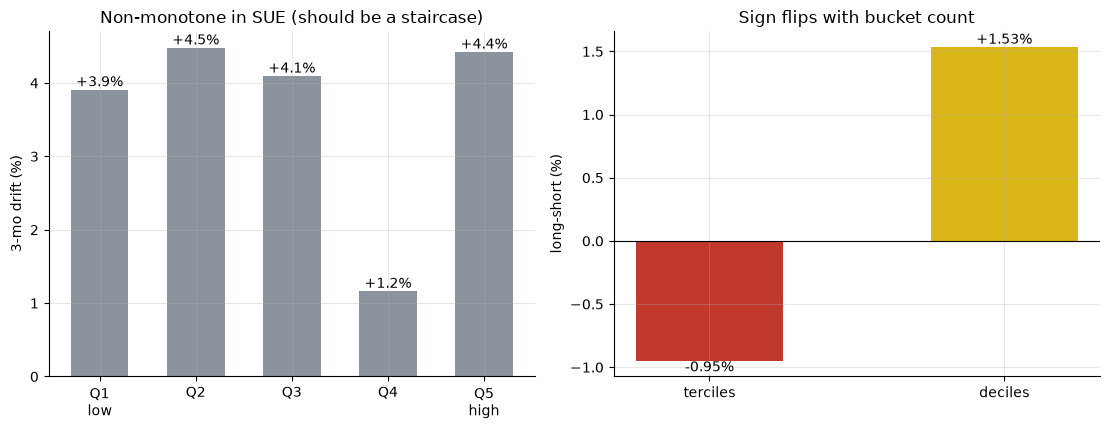

quintiles [3.91, 4.48, 4.1, 1.16, 4.42] | tercile -0.95 decile 1.53


In [3]:
H=63
if HAVE_REAL:
    fr = st.event_drift_frame(PRICES, ET, H)
    q5 = st.bucket_means(fr, n_buckets=5)*100
    terc = st.long_short_drift(fr, n_buckets=3)['ls_mean']*100
    dec = st.long_short_drift(fr, n_buckets=10)['ls_mean']*100
else:
    q5 = np.array(R['h63']['q5']); terc, dec = R['h63']['ls'], R['decile63_ls']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.2, 4.4))
a1.bar(['Q1\nlow','Q2','Q3','Q4','Q5\nhigh'], q5, color=GREY, width=.6)
for i,v in enumerate(q5): a1.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom')
a1.set_ylabel('3-mo drift (%)'); a1.set_title('Non-monotone in SUE (should be a staircase)')
a2.bar(['terciles','deciles'], [terc, dec], color=[RED, AMBER], width=.5)
for i,v in enumerate([terc, dec]): a2.annotate(f'{v:+.2f}%',(i,v),ha='center',
    va='bottom' if v>=0 else 'top')
a2.axhline(0,c='k',lw=.8); a2.set_ylabel('long-short (%)'); a2.set_title('Sign flips with bucket count')
plt.tight_layout(); plt.show()
print('quintiles', [round(float(x),2) for x in q5], '| tercile', round(terc,2), 'decile', round(dec,2))

> 💡 In plain words: the quintiles zig-zag (+3.9, +4.5, +4.1, +1.2, +4.4%) with no slope, and the long-short is **-0.95%** in terciles but **+1.53%** in deciles. A robust anomaly does not reverse when you re-slice the identical sort — H₂ rejected. This is the canonical fingerprint of noise.

### 4c · The placebos — nothing to rescue

A light in-notebook within-quarter block placebo (respects the earnings-season clustering); we quote the canonical fuller run from `results.md`.

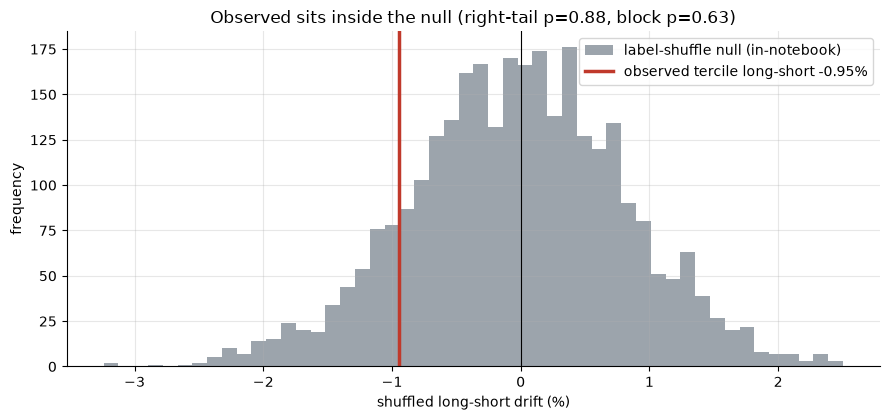

canonical (results.md): right-tail label-shuffle p=0.879, within-quarter block p=0.628


In [4]:
H=63
if HAVE_REAL:
    fr = st.event_drift_frame(PRICES, ET, H)
    obs = st.long_short_drift(fr, n_buckets=3)['ls_mean']*100
    pl = st.placebo_pvalue(fr, n_draws=3000, n_buckets=3)
    draws = pl['draws']*100
else:
    obs = R['h63']['ls']
    draws = np.random.default_rng(789).normal(0, 0.6, 3000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='label-shuffle null (in-notebook)')
ax.axvline(obs, c=RED, lw=2.5, label=f'observed tercile long-short {obs:+.2f}%')
ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('shuffled long-short drift (%)'); ax.set_ylabel('frequency')
ax.set_title(f"Observed sits inside the null (right-tail p={R['h63']['placebo_p']:.2f}, block p={R['h63']['block_p']:.2f})")
ax.legend(); plt.tight_layout(); plt.show()
print(f"canonical (results.md): right-tail label-shuffle p={R['h63']['placebo_p']:.3f}, within-quarter block p={R['h63']['block_p']:.3f}")

> 💡 In plain words: the observed spread sits *inside* the shuffle cloud — right-tail label-shuffle p = **0.88** (i.e. a random relabelling beats it most of the time), within-quarter block placebo p = **0.63**. There is no positive drift for the placebo to be surprised by.

### 4d · The cost sweep — nothing to erode

One-way costs × per-event turnover (4× one-way on a long-short round trip) + short-leg borrow, at 63 days.

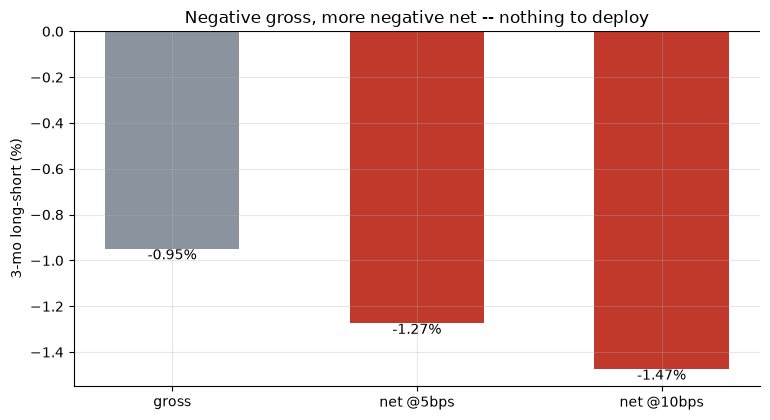

gross -0.95%  net@5 -1.27%  net@10 -1.47%


In [5]:
if HAVE_REAL:
    g = st.net_of_costs(PRICES, ET, 63, cost_bps=5.0)['gross']*100
    n5 = st.net_of_costs(PRICES, ET, 63, cost_bps=5.0)['net']*100
    n10 = st.net_of_costs(PRICES, ET, 63, cost_bps=10.0)['net']*100
else:
    g, n5, n10 = R['gross63'], R['c5_net'], R['c10_net']
fig, ax = plt.subplots(figsize=(7.8, 4.3))
ax.bar(['gross','net @5bps','net @10bps'], [g, n5, n10], color=[GREY, RED, RED], width=.55)
for i,v in enumerate([g,n5,n10]): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',va='top')
ax.axhline(0,c='k',lw=.8); ax.set_ylabel('3-mo long-short (%)')
ax.set_title('Negative gross, more negative net -- nothing to deploy')
plt.tight_layout(); plt.show()
print(f'gross {g:+.2f}%  net@5 {n5:+.2f}%  net@10 {n10:+.2f}%')

> 💡 In plain words: gross is already **-0.95%**; net of costs it's **-1.27%** (5 bps) to **-1.47%** (10 bps). Tradability = MIRAGE by default — there is no edge to charge costs against.

### 4e · Faithful-engine & power control — we know the truth here

Synthetic price panel + SUE events with a TUNABLE planted post-earnings drift. The null (edge = 0) is checked over **20 seeds**; a planted edge must light up.

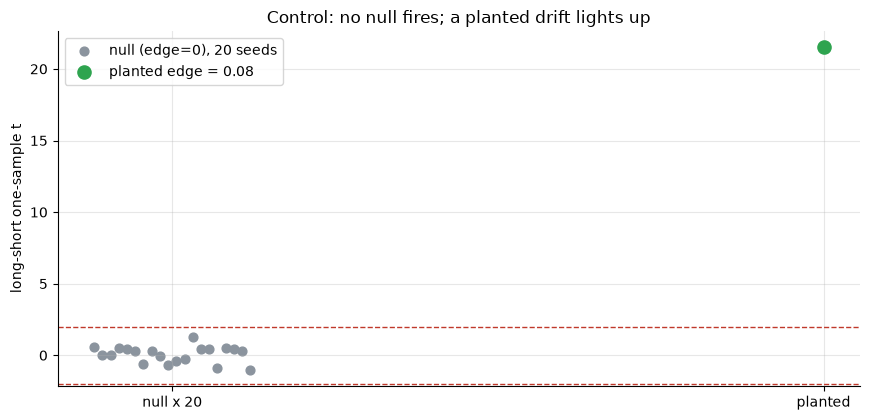

null mean t=+0.08 (sd 0.57), |t|>=2 in 0/20  |  planted t=+21.50


In [6]:
null_ts = []
for s_ in range(20):
    p, e = data.synthetic_sue(edge=0.0, seed=789 + s_)
    null_ts.append(st.synthetic_detect(p, e)['t'])
null_ts = np.asarray(null_ts)
pP, eP = data.synthetic_sue(edge=0.08, seed=789)
planted_t = st.synthetic_detect(pP, eP)['t']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.linspace(-.12,.12,20), null_ts, color=GREY, s=40, label='null (edge=0), 20 seeds')
ax.scatter([1], [planted_t], color=GREEN, s=90, zorder=5, label='planted edge = 0.08')
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1)
ax.set_xticks([0,1]); ax.set_xticklabels(['null x 20','planted'])
ax.set_ylabel('long-short one-sample t'); ax.set_title('Control: no null fires; a planted drift lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null mean t={null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/20  |  planted t={planted_t:+.2f}')

> 💡 In plain words: across 20 null worlds the detector averages t = +0.08 (sd 0.57) and **never** crosses the bar; a planted drift reads t = 21.5 (long-short +16.6%). The machinery is faithful and well-powered — so the flat real-tape result is a genuine *absence* of signal, not a broken detector. *(A power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — SUE tercile long-short -1.16% / -1.77% / -0.95% (1/2/3 mo, wrong sign); robust calendar-time NW t = -1.41 / -0.41 / +0.41 (never clears +2); non-monotone quintiles; sign flips tercile→decile (-0.95% → +1.53%); block placebo p = 0.63. The naive one-sample t of -2.48 is a clustering artifact, not a signal.
- **Tradability `MIRAGE`** — gross -0.95% at 63d, net -1.27% / -1.47% at 5/10 bps. Nothing to deploy.
- **Textbook PEAD replicates? `BUSTED`** — no monotone SUE gradient and a robust t pinned near zero on liquid large-cap survivors, exactly where the literature (Chordia et al. 2009; McLean-Pontiff 2016) predicts it should be weakest or gone.

## 6 · Going further

- **The liquidity story.** PEAD is documented to concentrate in small, illiquid, thinly-covered names; our basket is the opposite. The obvious follow-up is a small-cap / low-coverage universe — with survivorship handled via a point-in-time membership panel (the desk's opt-in guard).
- **Expectation model.** We use the seasonal random walk (Foster-Olsen-Shevlin). A richer analyst-expectations SUE is a different signal — and its own study ([369](../../369-earnings-revision-momentum/)).
- **Dedup map:** [363-pead-drift](../../363-pead-drift/) (price-gap/CAR sort, no fundamentals), [369-earnings-revision-momentum](../../369-earnings-revision-momentum/) (analyst revisions), [534-revenue-surprise-drift](../../534-revenue-surprise-drift/) (revenue SUR on this same basket — also empty). This study is the **SUE-sorted fundamental-EPS** portfolio drift.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*